Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


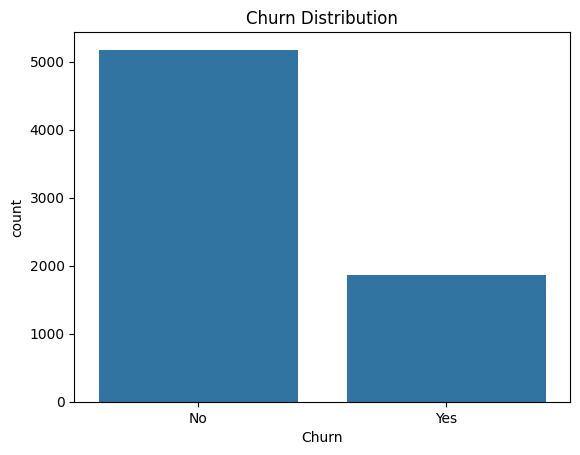

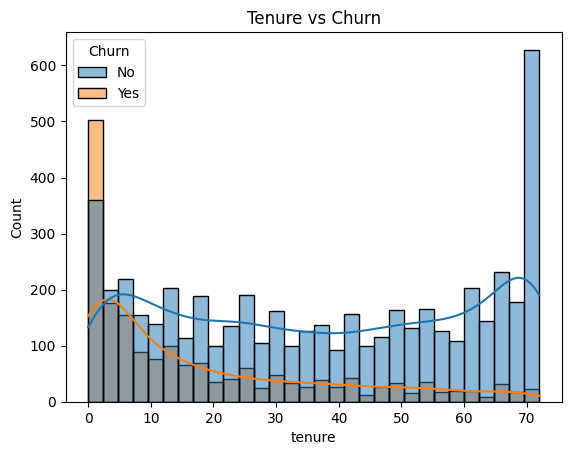

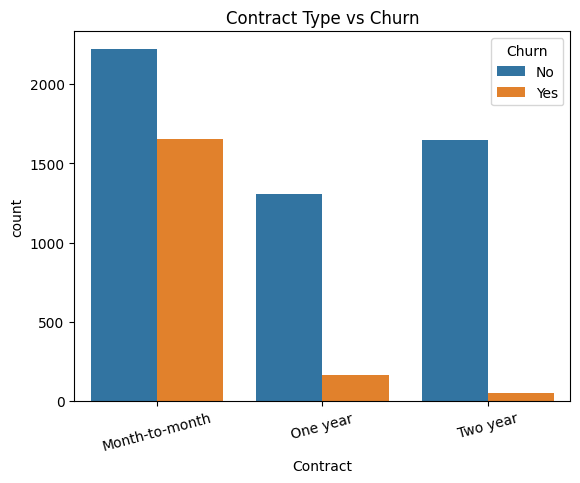

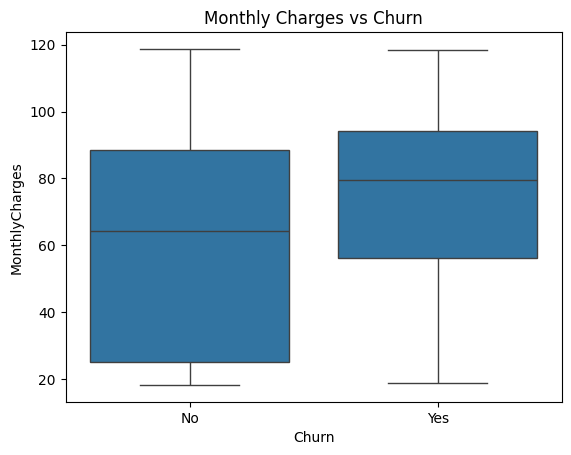

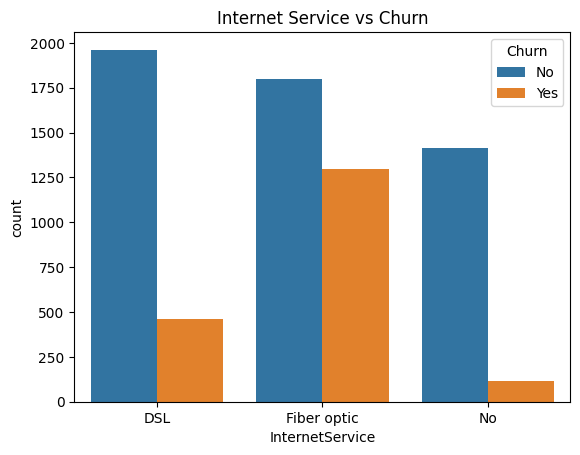

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv")
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True) * 100)

sns.countplot(x="Churn",data=df)
plt.title("Churn Distribution")
plt.show()

sns.histplot(data=df, x="tenure", hue="Churn", bins=30, kde=True)
plt.title("Tenure vs Churn")
plt.show()

sns.countplot(x="Contract",hue="Churn",data=df)
plt.title("Contract Type vs Churn")
plt.xticks(rotation=15)
plt.show()

sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

sns.countplot(x="InternetService", hue="Churn", data=df)
plt.title("Internet Service vs Churn")
plt.show()

df.to_csv("../data/processed/customers_clean.csv", index=False)



# Key Exploratory Data Analysis (EDA) Insights

- Customers with short tenure (new customers) have a much higher churn rate compared to long-term customers.
- Customers on month-to-month contracts churn significantly more than those on one-year or two-year contracts.
- Customers with higher monthly charges tend to churn more.
- Fiber optic internet users show a higher churn rate compared to DSL users.
- Overall, churn is imbalanced, with fewer customers leaving compared to those staying.

# Business Takeaway

- Focus on retaining new customers in the first few months.
- Encourage customers to move from month-to-month to long-term contracts.
- Review pricing and service quality for high-charge customers.


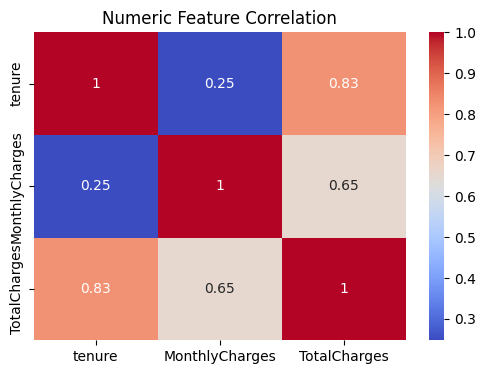

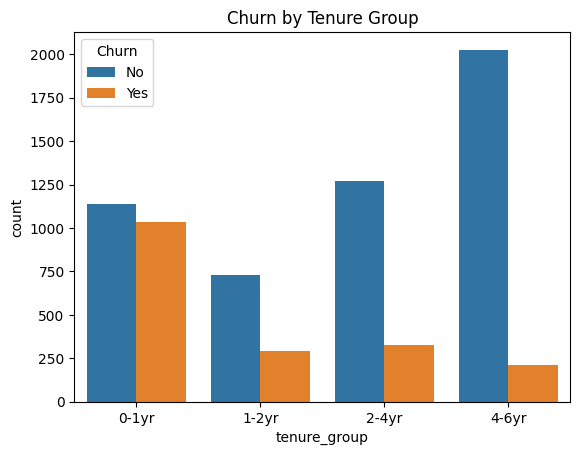

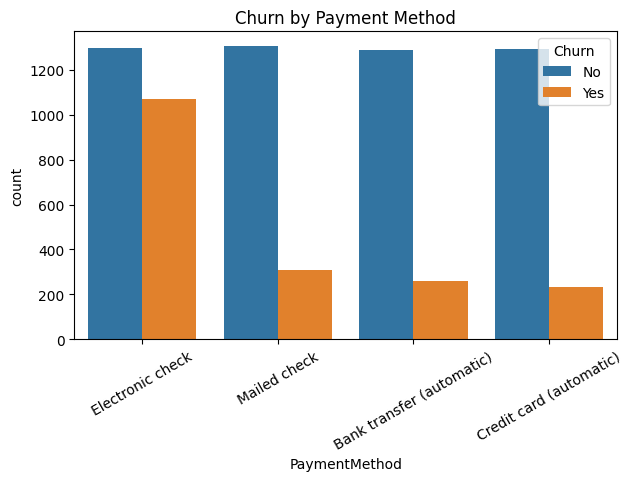

InternetService        DSL  Fiber optic         No
Contract                                          
Month-to-month   31.561290    54.916129  13.522581
One year         38.696538    36.591989  24.711473
Two year         37.050147    25.309735  37.640118


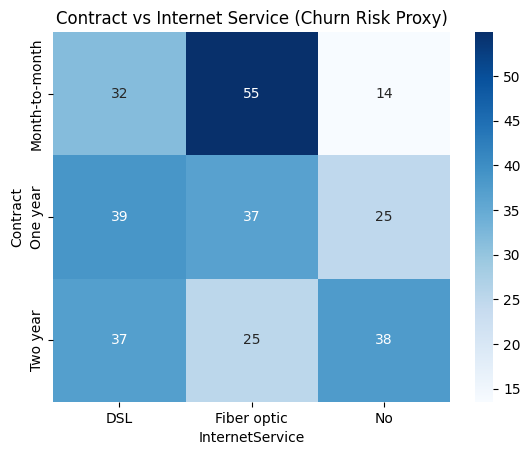

In [ ]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

plt.figure(figsize=(6,4))

sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Numeric Feature Correlation")
plt.show()

df["tenure_group"] = pd.cut(df["tenure"],
                            bins=[0, 12, 24, 48, 72],
                            labels=["0-1yr", "1-2yr", "2-4yr", "4-6yr"])

sns.countplot(x="tenure_group", hue="Churn", data=df)
plt.title("Churn by Tenure Group")
plt.show()

plt.figure(figsize=(7,4))
sns.countplot(x="PaymentMethod", hue="Churn", data=df)
plt.xticks(rotation=30)
plt.title("Churn by Payment Method")
plt.show()

ct = pd.crosstab(df["Contract"], df["InternetService"], normalize='index') * 100
print(ct)

sns.heatmap(ct, annot=True, cmap="Blues")
plt.title("Contract vs Internet Service (Churn Risk Proxy)")
plt.show()

df.to_csv("../data/processed/customers_clean.csv", index=False)


## 🔍 Deeper Exploratory Data Analysis (EDA) Insights 

- `TotalCharges` shows strong positive correlation with both `tenure` and `MonthlyCharges`, which makes sense because long-term customers accumulate higher total bills over time.
- Customers in the **0–1 year tenure group** churn the most, confirming that early retention is a key issue for the business.
- Customers who use **Electronic Check** as a payment method have noticeably higher churn rates compared to other payment methods.
- Customers with **month-to-month contracts + fiber optic internet** appear to form a high-risk churn segment.
- Features related to pricing and service type show stronger churn signals than demographic fields such as gender.

## 📌 Business Takeaways 

- Improving **customer onboarding and early engagement** may reduce churn significantly.
- Encouraging customers to move toward **long-term contracts** could stabilize the customer base.
- Payment method incentives (e.g., discounts for automatic bank transfers) might help reduce churn.
- Investigating service quality for **fiber optic customers** could address dissatisfaction in a critical churn segment.
